





























































# ADALINE desde cero: de la formulación matemática a una arquitectura computacional

## Parcial en casa — componente práctico

En el ejercicio anterior trabajamos con el perceptrón de Rosenblatt. Allí la arquitectura funcional fue construida conjuntamente y el trabajo consistió en completar las funciones que la componían.

En este ejercicio cambia deliberadamente el nivel de autonomía:

> **usted recibe el problema, la formulación matemática, una función fundamental ya implementada, datos, experimentos y criterios de integración; la arquitectura de software debe diseñarla usted.**

No existe una única arquitectura correcta. Dos soluciones pueden ser diferentes y ambas ser válidas si:

- las responsabilidades están bien separadas;
- los contratos de entrada y salida son claros;
- la implementación reproduce correctamente el algoritmo;
- las funciones se conectan de manera coherente;
- las pruebas permiten verificar el comportamiento esperado.

El cuaderno es **autocontenido**: no necesita un PDF externo ni archivos de datos adicionales.

### Qué debe entregar dentro de este mismo notebook

1. propuesta de arquitectura funcional;
2. diagrama de conexión entre funciones;
3. derivación de la regla de actualización;
4. implementación de ADALINE con NumPy;
5. validaciones con `raise ValueError`;
6. `type hints` y docstrings;
7. pruebas diseñadas por usted;
8. entrenamiento y seguimiento de la pérdida;
9. experimentos con el `learning rate`;
10. comparación entre variables en escalas distintas y variables estandarizadas;
11. evaluación sobre train, validation y test;
12. comparación conceptual entre perceptrón y ADALINE;
13. reflexión final sobre sus decisiones de arquitectura.

### Restricciones

- El núcleo de ADALINE debe implementarse con **NumPy**.
- No utilice una implementación equivalente de `scikit-learn`, TensorFlow, PyTorch u otra biblioteca.
- No utilice clases. La solución debe permanecer en una arquitectura funcional.
- Puede crear tantas funciones auxiliares como considere necesarias.
- Debe utilizar la función `actualizar_pesos_adaline` proporcionada.
- Para que las celdas posteriores puedan ejecutar arquitecturas diferentes, deberá respetar únicamente dos **interfaces públicas**:
  - `entrenar_adaline(...)`
  - `predecir_adaline(...)`

Estas dos firmas no determinan la arquitectura interna.

### Dependencias

En el ambiente del curso deben estar disponibles:

```bash
uv add numpy pandas matplotlib
```

El ambiente virtual no debe subirse al repositorio.

# 1. ¿Qué cambia respecto al perceptrón?

Ambos modelos parten de:

$$
z_i=\mathbf w^\top \tilde{\mathbf x}_i.
$$

La diferencia está en **cómo utilizan esa cantidad para aprender**.

### Perceptrón

$$
y_i z_i\le 0
\quad\Longrightarrow\quad
\mathbf w\leftarrow\mathbf w+\eta y_i\tilde{\mathbf x}_i.
$$

La pregunta esencial es:

> ¿la observación quedó bien o mal clasificada?

### ADALINE

Durante el entrenamiento ADALINE utiliza directamente la salida lineal:

$$
a_i=z_i=\mathbf w^\top\tilde{\mathbf x}_i,
$$

y define un error continuo:

$$
e_i=y_i-a_i.
$$

Por tanto, la magnitud del error sí participa en el aprendizaje.

En este ejercicio:

$$
y_i\in\{-1,+1\}.
$$

La función signo aparecerá **solo para convertir la salida lineal en una clase durante inferencia**.

# 2. La función que queremos minimizar

Trabajaremos con:

$$
\boxed{
L(\mathbf w)=
\frac{1}{2n}
\sum_{i=1}^{n}
\left(
y_i-\mathbf w^\top\tilde{\mathbf x}_i
\right)^2
}
$$

o, matricialmente,

$$
L(\mathbf w)
=
\frac{1}{2n}
\left\|
\mathbf y-\tilde X\mathbf w
\right\|_2^2.
$$

Antes de programar, responda:

1. ¿por qué el cuadrado evita que errores positivos y negativos se cancelen?;
2. ¿qué efecto tiene sobre errores de distinta magnitud?;
3. ¿por qué el factor \(1/2\) es conveniente?;
4. ¿qué variable estamos optimizando?

**Respuesta:**

> 1. $(e_i)^2\geq0$ por propiedad de los números reales, luego, sin importar el resultado de $e_i$, si es positivo o negativo, la suma que sucede a la operación de cuadrado hace que no haya elementos y sus inversos aditivos que se puedan cancelar. 
> 2. Se tiene, por propiedad del cuadrado, que los errores donde $-1\leq e_i\leq1$ terminan en el intervalo $0\leq(e_i)^2\leq1$, con $e_i\geq(e_i)^2$. Luego, los valores dentro de ese intervalo no penalizan el error en la misma medida que lo hacen todos los valores fuera de él. 
> 3. En este caso, se multiplica la suma por un factor $\frac{1}{2}$, que se introduce por conveniencia, pues al tomar la derivada respecto a alguno de los parámetros dentro del cuadrado, como $\frac{de_i}{dw}$, se cancela el factor $\frac{1}{2}$ con un $2$. 
> 4. La función $L(w)$ busca optimizar el vector de parámetros $w^T$, pues se trata de que los errores entre las predicciones y los valores reales sean, en conjunto, lo más pequeños posible.

## 2.1 Derivación guiada

Defina:

$$
\mathbf e=\mathbf y-\tilde X\mathbf w.
$$

Entonces:

$$
L(\mathbf w)
=
\frac{1}{2n}\mathbf e^\top\mathbf e.
$$

Complete la derivación hasta obtener:

$$\nabla_{\mathbf w}L=\boxed{
-\frac{1}{n}\tilde X^\top\mathbf e
}
$$

Luego use:

$$\mathbf w_{\text{nuevo}}=\mathbf w-\eta\nabla_{\mathbf w}L
$$

para escribir la regla de actualización:

$$\boxed{\mathbf w_{\text{nuevo}}=\mathbf w + \frac{\eta}{n}\tilde X^\top\mathbf e
}
$$

<details>
<summary><strong>Pista 1 — dimensiones</strong></summary>

Si

$$
\tilde X\in\mathbb R^{n\times(d+1)}
\quad\text{y}\quad
\mathbf e\in\mathbb R^n,
$$

entonces el gradiente debe pertenecer a $$\mathbb R^{d+1}$$, igual que $$\mathbf w$$.

</details>

<details>
<summary><strong>Pista 2 — estructura del gradiente</strong></summary>

La expresión debe contener $$\tilde X^\top\mathbf e$$. Piense además en el signo y en el factor \(1/n\).

</details>

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=5, suppress=True)

# 3. Datos autocontenidos

El cuaderno genera los datos internamente.

Usaremos un conjunto sintético binario de dos características. Más adelante construiremos una versión equivalente en la que una característica tenga una escala mucho mayor.

Las funciones de generación, partición y estandarización **ya están implementadas** y no forman parte de la arquitectura de ADALINE.

In [2]:
def crear_datos_sinteticos(
    n: int = 600,
    semilla: int = 2026,
) -> tuple[np.ndarray, np.ndarray]:
    """Genera un problema binario bidimensional."""
    if n < 40:
        raise ValueError("n debe ser al menos 40.")
    if n % 2 != 0:
        raise ValueError("n debe ser par.")

    rng = np.random.default_rng(semilla)
    mitad = n // 2

    clase_negativa = rng.normal(
        loc=(-1.5, -1.0),
        scale=(0.70, 0.60),
        size=(mitad, 2),
    )
    clase_positiva = rng.normal(
        loc=(1.5, 1.0),
        scale=(0.70, 0.60),
        size=(mitad, 2),
    )

    X = np.vstack((clase_negativa, clase_positiva))
    y = np.concatenate(
        (-np.ones(mitad, dtype=int), np.ones(mitad, dtype=int))
    )

    idx = rng.permutation(n)
    return X[idx], y[idx]


def particion_estratificada(
    X: np.ndarray,
    y: np.ndarray,
    proporcion_train: float = 0.70,
    proporcion_val: float = 0.15,
    semilla: int = 2026,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Divide train/validation/test manteniendo el balance."""
    if not 0 < proporcion_train < 1:
        raise ValueError("proporcion_train debe pertenecer a (0, 1).")
    if not 0 < proporcion_val < 1:
        raise ValueError("proporcion_val debe pertenecer a (0, 1).")
    if proporcion_train + proporcion_val >= 1:
        raise ValueError("Debe quedar una proporción positiva para test.")

    rng = np.random.default_rng(semilla)
    train_idx, val_idx, test_idx = [], [], []

    for etiqueta in np.unique(y):
        idx = rng.permutation(np.flatnonzero(y == etiqueta))
        n_clase = len(idx)
        n_train = int(round(proporcion_train * n_clase))
        n_val = int(round(proporcion_val * n_clase))

        train_idx.extend(idx[:n_train])
        val_idx.extend(idx[n_train:n_train + n_val])
        test_idx.extend(idx[n_train + n_val:])

    train_idx = rng.permutation(train_idx)
    val_idx = rng.permutation(val_idx)
    test_idx = rng.permutation(test_idx)

    return (
        X[train_idx], y[train_idx],
        X[val_idx], y[val_idx],
        X[test_idx], y[test_idx],
    )


def estandarizar_desde_train(
    X_train: np.ndarray,
    X_val: np.ndarray,
    X_test: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Estandariza usando únicamente media y desviación de train."""
    media = X_train.mean(axis=0)
    desviacion = X_train.std(axis=0)

    if np.any(np.isclose(desviacion, 0.0)):
        raise ValueError("No se puede estandarizar una característica constante.")

    return (
        (X_train - media) / desviacion,
        (X_val - media) / desviacion,
        (X_test - media) / desviacion,
        media,
        desviacion,
    )

# 4. EDA antes de entrenar

Verifique forma, tipos, valores faltantes, balance de clases y geometría aproximada.

In [3]:
X, y = crear_datos_sinteticos()

datos = pd.DataFrame(
    {
        "x1": X[:, 0],
        "x2": X[:, 1],
        "y": y,
    }
)

datos.head()

,x1,x2,y
0,0.504078,1.376973,1
1,2.415865,0.059543,1
2,-0.916254,-0.317370,-1
3,1.971840,1.278964,1
4,-2.011872,-0.839371,-1


In [4]:
print("Forma:", datos.shape)

print("\nTipos:")
print(datos.dtypes)

print("\nValores faltantes:")
print(datos.isna().sum())

print("\nDistribución de clases:")
print(datos["y"].value_counts().sort_index())

print("\nResumen:")
display(datos.describe())

Forma: (600, 3)

Tipos:
x1    float64
x2    float64
y       int64
dtype: object

Valores faltantes:
x1    0
x2    0
y     0
dtype: int64

Distribución de clases:
y
-1    300
 1    300
Name: count, dtype: int64

Resumen:


,x1,x2,y
count,600.000000,600.000000,600.000000
mean,0.016341,-0.013780,0.000000
std,1.632393,1.151417,1.000834
min,-4.123190,-2.866853,-1.000000
25%,-1.444694,-0.972564,-1.000000
50%,0.045144,0.002315,0.000000
75%,1.459685,0.976449,1.000000
max,3.209089,2.458614,1.000000


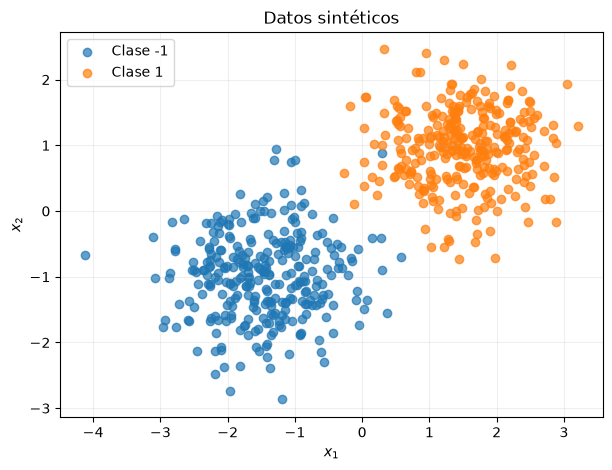

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))

for etiqueta in (-1, 1):
    grupo = datos[datos["y"] == etiqueta]
    ax.scatter(
        grupo["x1"],
        grupo["x2"],
        alpha=0.7,
        label=f"Clase {etiqueta}",
    )

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Datos sintéticos")
ax.legend()
ax.grid(alpha=0.2)
plt.savefig("Datos sintéticos.png", dpi=800, bbox_inches="tight")
plt.show()

### Lectura previa

1. ¿parece razonable una frontera lineal?;
2. ¿hay solapamiento?;
3. ¿esta gráfica demuestra separabilidad lineal?;
4. ¿por qué sigue siendo útil observarla?

**Respuesta:**

> 1. Esta gráfica presenta una posible frontera lineal, pues, según Aggarwal (2023), existe una clara distinción entre las clases a través de un hiperplano lineal. 
> 2. No parece haber un solapamiento explícito en la mayoría de los datos, sino que son unos pocos los que sobrepasan la posible frontera lineal. 
> 3. Aunque existe una posible frontera lineal, esto no demuestra que los datos presenten separabilidad lineal, sino que para ello se debe comprobar matemáticamente que existe un vector de pesos $\mathbf{w}$ que permita clasificar correctamente todas las instancias de entrenamiento. Esto puede comprobarse mediante un algoritmo de clasificación lineal, como el perceptrón o, en este caso, ADALINE, verificando que la función de clasificación correspondiente a $\mathbf{w}^\top\mathbf{x}$ permita distinguir correctamente las clases. 
> 4. Vale la pena seguir observando la gráfica, pues de ella se puede adquirir una primera impresión de la estructura de los datos, en particular, del solapamiento de los datos, su agrupación y posibles valores atípicos. Además, puede ayudar a determinar el posible modelo a aplicar a los datos.

# 5. Train, validation y test

Los pesos deben aprenderse únicamente a partir de `train`.

In [6]:
(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
) = particion_estratificada(X, y)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (420, 2) (420,)
Validation: (90, 2) (90,)
Test: (90, 2) (90,)


# 6. Una pieza ya implementada: actualización de pesos

La siguiente función se entrega resuelta.

Con:

$$
\mathbf a=\tilde X\mathbf w,
\qquad
\mathbf e=\mathbf y-\mathbf a,
$$

implementa:

$$
\boxed{
\mathbf w_{\text{nuevo}}
=
\mathbf w+
\frac{\eta}{n}
\tilde X^\top\mathbf e
}
$$

Es una actualización **batch**: usa todo el conjunto recibido para producir una actualización global.

Estudie la función. **No la modifique.**

In [7]:
def actualizar_pesos_adaline(
    X_aug: np.ndarray,
    y: np.ndarray,
    w: np.ndarray,
    eta: float,
) -> np.ndarray:
    """Actualiza los pesos de ADALINE mediante batch gradient descent.

    Args:
        X_aug: Matriz de características con x0 = 1.
        y: Vector de etiquetas en {-1, +1}.
        w: Vector actual de pesos.
        eta: Tasa de aprendizaje estrictamente positiva.

    Returns:
        Vector de pesos actualizado.

    Raises:
        ValueError: Si las dimensiones son incompatibles, aparecen
            valores no finitos o eta no es positiva.
    """
    if X_aug.ndim != 2:
        raise ValueError("X_aug debe ser una matriz bidimensional.")
    if y.ndim != 1:
        raise ValueError("y debe ser un vector unidimensional.")
    if w.ndim != 1:
        raise ValueError("w debe ser un vector unidimensional.")
    if X_aug.shape[0] != y.shape[0]:
        raise ValueError("X_aug e y deben tener el mismo número de observaciones.")
    if X_aug.shape[1] != w.shape[0]:
        raise ValueError("El número de columnas de X_aug debe coincidir con len(w).")
    if not np.isfinite(X_aug).all():
        raise ValueError("X_aug contiene valores no finitos.")
    if not np.isfinite(y).all():
        raise ValueError("y contiene valores no finitos.")
    if not np.isfinite(w).all():
        raise ValueError("w contiene valores no finitos.")
    if eta <= 0:
        raise ValueError("eta debe ser estrictamente positiva.")

    salida = X_aug @ w
    error = y - salida
    w_nuevo = w + eta * (X_aug.T @ error) / len(y)

    return w_nuevo

## 6.1 Compruebe una actualización a mano

Considere:

$$
\tilde X=
\begin{bmatrix}
1&0&0\\
1&1&1
\end{bmatrix},
\quad
\mathbf y=
\begin{bmatrix}
-1\\
1
\end{bmatrix},
\quad
\mathbf w=
\begin{bmatrix}
0\\0\\0
\end{bmatrix},
\quad
\eta=0.1.
$$

Calcule manualmente:

1. $$\tilde X\mathbf w = \begin{bmatrix}0\\0\end{bmatrix} $$
2. $$\mathbf e= \begin{bmatrix}-1\\1\end{bmatrix}$$
3. $$\tilde X^\top\mathbf e = \begin{bmatrix}0\\1\\1\end{bmatrix}$$
4. $$\mathbf w_{\text{nuevo}}= \begin{bmatrix}0\\ 0.05 \\ 0.05\end{bmatrix}$$



**Resultado esperado por usted:**

$$
\mathbf w_{\text{nuevo}}
=
\boxed{\begin{bmatrix}0\\ 0.05 \\ 0.05\end{bmatrix}}
$$

In [8]:
# COMPROBACIÓN — NO MODIFICAR

X_manual = np.array(
    [
        [1.0, 0.0, 0.0],
        [1.0, 1.0, 1.0],
    ]
)
y_manual = np.array([-1.0, 1.0])
w_manual = np.zeros(3)

w_actualizado = actualizar_pesos_adaline(
    X_manual,
    y_manual,
    w_manual,
    eta=0.1,
)

print("Pesos obtenidos:", w_actualizado)
assert np.allclose(w_actualizado, np.array([0.0, 0.05, 0.05]))
print("✓ La función proporcionada reproduce el cálculo esperado.")

Pesos obtenidos: [0.   0.05 0.05]
✓ La función proporcionada reproduce el cálculo esperado.


# 7. Diseñe antes de programar

## No empiece por el código

La función anterior resuelve una operación, no el algoritmo completo.

Piense en necesidades como:

- validar datos e hiperparámetros;
- incorporar \(x_0=1\);
- inicializar pesos;
- calcular salida lineal;
- calcular pérdida;
- coordinar épocas;
- guardar historial;
- convertir salida lineal en una clase;
- predecir sobre nuevas observaciones.

**No significa que cada elemento deba convertirse en una función.** La descomposición es parte del ejercicio.

Complete esta tabla:

| Función propuesta | Responsabilidad | Entradas | Salida | Dependencias |
|---|---|---|---|---|
|validar_datos |dimension, tipo de dato, balance de datos correctos| X y| "Datos correctos"| Conjunto de datos|
|designar_hiperparametros|inicializar hiperparametros|cantidad de filas de X, valor numerico mayor que 0, dimensión d+1|n, $\eta$, $w^0$| X y|
|agregar_sesgo|agregar el sego $x_0$ a X|X, cantidad de filas de X|X_aug| X|
|entrada_neta|calcular y asignar|w,X_aug|z_i y a_i|agregar_sesgo, designar_hiperparametros|
|clasificacion_error|calcular, guardar el error, determinar si es 0| y, a_i| e_i| y, entrada_neta|
|calculo_gradiente|Calcular, guardar gradiente|n, X_aug, e_i| $\nabla_{\mathbf w}L(\mathbf w)$| claasificacion_error, designar_hiperparametros|
|actualizar_pesos_adaline|calcula el nuevo vector de pesos|X_aug, y, w, $\eta$|w_nuevo|calculo_gradiente,  claasificacion_error, designar_hiperparametros|
|signo|definir la funcion sign|z_i| $\{1,-1\}$|entrada_neta|
|entrenar_una_epoca|entrena la primpera epoca|entrada_neta, clasificacion_error, calculo_gradiente, actualizar_pesos_adaline|calculo_perdida|funciones pasadas|
|entrenar_adaline|repetir epocas hasta un umbral $\epsilon$|entrenar_una_epoca|"umbral alcanzado", w_optimo|entrenar_una_epoca|
|predecir|aplicar el modelo a datos no vistos|w_optimo|calculo_perdida, Tabla de datos predichos y reales|entrenar_adaline|

### Diagrama

Reemplace las cajas por su propuesta:

```text
datos
  │
  ▼
[validar datos]
  │
  ▼
[agregar sesgo]   [designar hiperparametros]
  │                    │
  ▼                    ▼
[entrenar ADALINE]
  │
  ▼
[Entrenar una epoca]
  │
  ├──────────────►[entrenar ADALINE]
  ▼
[Entrada neta]
  │
  ▼
[clasificación del error]
  │
  ├──────────────►[Entrada neta]
  ▼
[Calculo gradiente]
  │
  ▼
[actualizar pesos]
  │
  ▼
[Entrenar una epoca]
  │
  ▼
pesos finales

```

### Justificación

¿Por qué separó las responsabilidades de esa manera?

> La separación de responsabilidades permite dividir ADALINE en funciones específicas, donde cada una realiza una tarea concreta del algoritmo, como validar los datos, calcular la salida, obtener el error, calcular el gradiente o actualizar los pesos. Las funciones de mayor nivel coordinan estas operaciones para realizar el entrenamiento completo, mientras que signo se mantiene independiente porque se utiliza para clasificar la salida una vez realizado el entrenamiento. Esto facilita la comprensión, comprobación, reutilización y modificación del algoritmo.

# 8. Pseudocódigo del comportamiento esperado

Este pseudocódigo **no define nombres de funciones**.

```text
RECIBIR X, y, eta y número de épocas

VALIDAR las entradas

INCORPORAR x0 = 1

INICIALIZAR los pesos

PARA cada época:

    ACTUALIZAR los pesos mediante actualizar_pesos_adaline(...)

    CALCULAR la salida lineal con los pesos ya actualizados

    CALCULAR la pérdida de la época

    GUARDAR:
        - número de época
        - pérdida
        - copia de los pesos

DEVOLVER pesos finales e historial
```

Para inferencia:

```text
RECIBIR X y pesos entrenados

INCORPORAR x0 = 1

CALCULAR salida lineal

SI salida > 0:
    clase = +1
EN OTRO CASO:
    clase = -1

DEVOLVER predicciones
```

La función signo **no interviene en la pérdida usada para entrenar ADALINE**.

<details>
<summary><strong>Pista 3 — historial</strong></summary>

Cada época debe permitir recuperar:

- número de época;
- pérdida;
- una copia de los pesos.

</details>

<details>
<summary><strong>Pista 4 — si la pérdida aumenta</strong></summary>

Revise el signo de la actualización, el valor de \(\eta\), que la pérdida use la salida lineal y la escala de las características.

</details>

<details>
<summary><strong>Pista 5 — sesgo</strong></summary>

Mantenga la convención:

\[
x_0=1,
\qquad
w_0 \text{ actúa como sesgo}.
\]

No introduzca un `b` separado.

</details>

# 9. Implemente su arquitectura

Utilice las siguientes celdas para sus funciones auxiliares.

Se espera:

- `type hints`;
- docstrings;
- `raise ValueError` cuando corresponda;
- responsabilidades claras.

Puede añadir más celdas.

In [9]:
# CELDA DE IMPLEMENTACIÓN 1
def validar_datos(X: np.ndarray, y: np.ndarray) -> bool:
    """Valida dimensiones, tipos numéricos y valores de X e y."""
    if X.ndim != 2:
        raise ValueError("X debe ser una matriz bidimensional.")

    if y.ndim != 1:
        raise ValueError("y debe ser un vector unidimensional.")

    if X.shape[0] != y.shape[0]:
        raise ValueError("X e y deben tener el mismo número de observaciones.")

    if not np.issubdtype(X.dtype, np.number):
        raise TypeError("X debe contener datos numéricos.")

    if not np.issubdtype(y.dtype, np.number):
        raise TypeError("y debe contener datos numéricos.")

    if not np.isfinite(X).all():
        raise ValueError("X contiene valores no finitos.")

    if not np.isfinite(y).all():
        raise ValueError("y contiene valores no finitos.")

    if not np.isin(y, [-1, 1]).all():
        raise ValueError("Las etiquetas de y deben pertenecer a {-1, +1}.")

    return True


def designar_hiperparametros(
    X: np.ndarray,
    eta: float,
) -> tuple[int, float, np.ndarray]:
    """Inicializa los hiperparámetros y el vector inicial de pesos."""
    if X.ndim != 2:
        raise ValueError("X debe ser una matriz bidimensional.")

    if not np.isfinite(X).all():
        raise ValueError("X contiene valores no finitos.")

    if eta <= 0:
        raise ValueError("eta debe ser estrictamente positiva.")

    n = X.shape[0]
    d = X.shape[1]

    w0 = np.zeros(d + 1, dtype=float)

    return n, eta, w0


def agregar_sesgo(
    X: np.ndarray,
) -> np.ndarray:
    """Agrega la columna x0 = 1 a la matriz X."""
    if X.ndim != 2:
        raise ValueError("X debe ser una matriz bidimensional.")

    if not np.isfinite(X).all():
        raise ValueError("X contiene valores no finitos.")

    columna_sesgo = np.ones((X.shape[0], 1), dtype=X.dtype)

    X_aug = np.hstack((columna_sesgo, X))

    return X_aug




In [10]:
# CELDA DE IMPLEMENTACIÓN 2
def entrada_neta(
    w: np.ndarray,
    X_aug: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """Calcula la entrada neta y la salida lineal de ADALINE."""
    if X_aug.ndim != 2:
        raise ValueError("X_aug debe ser una matriz bidimensional.")

    if w.ndim != 1:
        raise ValueError("w debe ser un vector unidimensional.")

    if X_aug.shape[1] != w.shape[0]:
        raise ValueError(
            "El número de columnas de X_aug debe coincidir con len(w)."
        )

    if not np.isfinite(X_aug).all():
        raise ValueError("X_aug contiene valores no finitos.")

    if not np.isfinite(w).all():
        raise ValueError("w contiene valores no finitos.")

    z = X_aug @ w
    a = z.copy()

    return z, a


def clasificacion_error(
    y: np.ndarray,
    a: np.ndarray,
) -> np.ndarray:
    """Calcula el error entre las etiquetas reales y la salida lineal."""
    if y.ndim != 1:
        raise ValueError("y debe ser un vector unidimensional.")

    if a.ndim != 1:
        raise ValueError("a debe ser un vector unidimensional.")

    if y.shape != a.shape:
        raise ValueError("y y a deben tener las mismas dimensiones.")

    if not np.isfinite(y).all():
        raise ValueError("y contiene valores no finitos.")

    if not np.isfinite(a).all():
        raise ValueError("a contiene valores no finitos.")

    error = y - a

    return error


def calculo_gradiente(
    n: int,
    X_aug: np.ndarray,
    error: np.ndarray,
) -> np.ndarray:
    """Calcula el gradiente de la función de pérdida de ADALINE."""
    if n <= 0:
        raise ValueError("n debe ser estrictamente positivo.")

    if X_aug.ndim != 2:
        raise ValueError("X_aug debe ser una matriz bidimensional.")

    if error.ndim != 1:
        raise ValueError("error debe ser un vector unidimensional.")

    if X_aug.shape[0] != error.shape[0]:
        raise ValueError(
            "X_aug y error deben tener el mismo número de observaciones."
        )

    if not np.isfinite(X_aug).all():
        raise ValueError("X_aug contiene valores no finitos.")

    if not np.isfinite(error).all():
        raise ValueError("error contiene valores no finitos.")

    gradiente = -(X_aug.T @ error) / n

    return gradiente


def signo(z: np.ndarray) -> np.ndarray:
    """Transforma la salida lineal en etiquetas {-1, +1}."""
    if z.ndim != 1:
        raise ValueError("z debe ser un vector unidimensional.")

    if not np.isfinite(z).all():
        raise ValueError("z contiene valores no finitos.")

    return np.where(z >= 0, 1, -1)

In [11]:
# CELDA DE IMPLEMENTACIÓN 3

def entrenar_una_epoca(
    X_aug: np.ndarray,
    y: np.ndarray,
    w: np.ndarray,
    eta: float,
) -> tuple[np.ndarray, float]:
    """Ejecuta una época completa de entrenamiento de ADALINE.

    Returns:
        w_nuevo: Vector de pesos actualizado.
        perdida: Valor de la función de pérdida de la época.
    """
    # Salida lineal de ADALINE
    z, a = entrada_neta(w, X_aug)

    # Error
    error = clasificacion_error(y, a)

    # Gradiente
    gradiente = calculo_gradiente(
        len(y),
        X_aug,
        error
    )

    # Actualización de pesos
    w_nuevo = actualizar_pesos_adaline(
        X_aug,
        y,
        w,
        eta
    )

    # Función de pérdida:
    # L(w) = (1 / 2n) * sum(e_i^2)
    perdida = np.sum(error ** 2) / (2 * len(y))

    return w_nuevo, perdida





# 10. Interfaces de integración

Su arquitectura interna es libre, pero las celdas posteriores necesitan dos puntos de entrada comunes.

## 10.1 `entrenar_adaline`

El historial debe tener exactamente:

```python
{
    "epoca": ...,
    "perdida": ...,
    "w": ...,
}
```

La pérdida registrada debe corresponder a los pesos **después de la actualización de esa época**.

No se requiere `early stopping`: ejecute exactamente `max_epocas` épocas.

In [12]:
def entrenar_adaline(
    X: np.ndarray,
    y: np.ndarray,
    eta: float = 0.05,
    max_epocas: int = 100,
) -> tuple[np.ndarray, list[dict[str, object]]]:
    """Entrena ADALINE mediante batch gradient descent.

    Args:
        X: Matriz de características originales.
        y: Vector de etiquetas en {-1, +1}.
        eta: Tasa de aprendizaje estrictamente positiva.
        max_epocas: Número de épocas.

    Returns:
        Tupla (w, historial). Cada registro contiene
        'epoca', 'perdida' y 'w'.

    Raises:
        ValueError: Si los datos o hiperparámetros incumplen el contrato.
    """

    # Validar los datos
    validar_datos(X, y)

    # Validar max_epocas
    if not isinstance(max_epocas, (int, np.integer)):
        raise ValueError(
            "max_epocas debe ser un entero."
        )

    if max_epocas <= 0:
        raise ValueError(
            "max_epocas debe ser un entero estrictamente positivo."
        )

    # Agregar columna de sesgo x0 = 1
    X_aug = agregar_sesgo(X)

    # Inicializar pesos
    n, eta, w = designar_hiperparametros(
        X,
        eta
    )

    # Crear historial vacío
    historial = []

    # Entrenamiento por épocas
    for epoca in range(1, max_epocas + 1):

        # Entrenar una época
        w, perdida = entrenar_una_epoca(
            X_aug,
            y,
            w,
            eta
        )

        # Guardar resultados de la época
        historial.append({
            "epoca": epoca,
            "perdida": perdida,
            "w": w.copy()
        })

    # Devolver pesos finales e historial
    return w, historial

In [13]:


w, historial = entrenar_adaline(
    X,
    y,
    eta=0.05,
    max_epocas=10
)

print("w =", w)
print("historial =", historial)



w = [-0.00065  0.3515   0.23813]
historial = [{'epoca': 1, 'perdida': np.float64(0.5), 'w': array([0.     , 0.07379, 0.04867])}, {'epoca': 2, 'perdida': np.float64(0.35774482245232114), 'w': array([-0.00003,  0.13424,  0.08877])}, {'epoca': 3, 'perdida': np.float64(0.2619504365793716), 'w': array([-0.00007,  0.18373,  0.12183])}, {'epoca': 4, 'perdida': np.float64(0.19744023464577357), 'w': array([-0.00014,  0.22425,  0.14912])}, {'epoca': 5, 'perdida': np.float64(0.1539952090059988), 'w': array([-0.00021,  0.2574 ,  0.17166])}, {'epoca': 6, 'perdida': np.float64(0.1247344951258584), 'w': array([-0.00029,  0.28451,  0.19031])}, {'epoca': 7, 'perdida': np.float64(0.10502492902028689), 'w': array([-0.00038,  0.30665,  0.20576])}, {'epoca': 8, 'perdida': np.float64(0.09174681039731736), 'w': array([-0.00047,  0.32474,  0.21858])}, {'epoca': 9, 'perdida': np.float64(0.0827995127734153), 'w': array([-0.00056,  0.33948,  0.22924])}, {'epoca': 10, 'perdida': np.float64(0.07676859175949408), '

## 10.2 `predecir_adaline`

Durante inferencia:

$$
\hat y=
\begin{cases}
+1,&z>0,\\
-1,&z\le0.
\end{cases}
$$

In [14]:
def predecir_adaline(
    X: np.ndarray,
    w: np.ndarray,
) -> np.ndarray:
    """Obtiene predicciones binarias con un ADALINE entrenado.

    Args:
        X: Matriz de características originales.
        w: Vector de pesos entrenado.

    Returns:
        Vector de predicciones en {-1, +1}.
    """

    # Validar dimensiones
    if X.ndim != 2:
        raise ValueError("X debe ser una matriz bidimensional.")

    if w.ndim != 1:
        raise ValueError(
            "w debe ser un vector unidimensional."
        )

    # Validar compatibilidad entre X y w
    if X.shape[1] + 1 != w.shape[0]:
        raise ValueError(
            "La dimensión de X no es compatible con w."
        )

    # Validar valores finitos
    if not np.isfinite(X).all():
        raise ValueError(
            "X contiene valores no finitos."
        )

    if not np.isfinite(w).all():
        raise ValueError(
            "w contiene valores no finitos."
        )

    # Agregar x0 = 1
    X_aug = agregar_sesgo(X)

    # Calcular salida lineal de ADALINE
    z, _ = entrada_neta(w, X_aug)

    # Convertir salida lineal en etiquetas {-1, +1}
    predicciones = signo(z)

    return predicciones

# 11. Diseñe sus propias pruebas

En el perceptrón las pruebas fueron proporcionadas. Aquí debe proponerlas usted.

Incluya **al menos cuatro pruebas** relevantes.

Algunas preguntas que pueden inspirarlas:

- ¿se rechazan dimensiones incompatibles?;
- ¿se rechaza \(\eta\le0\)?;
- ¿la pérdida es cero cuando la salida coincide exactamente con \(y\)?;
- ¿la representación con sesgo tiene la forma esperada?;
- ¿las predicciones pertenecen a \(\{-1,+1\}\)?;
- ¿el historial tiene una entrada por época?;
- ¿los pesos almacenados en distintas épocas son copias independientes?

No tiene que utilizar estas mismas pruebas.

In [15]:
# PRUEBAS DEL ESTUDIANTE

import numpy as np

# ---------------------------------------------------------
# Prueba 1: validar_datos rechaza dimensiones incompatibles
# ---------------------------------------------------------

def test_validar_datos_dimensiones():
    X = np.array([
        [1.0, 2.0],
        [3.0, 4.0]
    ])

    y = np.array([1.0])

    try:
        validar_datos(X, y)
        assert False, "Debió producirse un ValueError."
    except ValueError:
        print("la prueba es correcta")

test_validar_datos_dimensiones()

la prueba es correcta


In [16]:
# ---------------------------------------------------------
# Prueba 2: validar_datos rechaza etiquetas diferentes
# de {-1, +1}
# ---------------------------------------------------------

def test_validar_datos_etiquetas():
    X = np.array([
        [1.0, 2.0],
        [3.0, 4.0]
    ])

    y = np.array([0.0, 1.0])

    try:
        validar_datos(X, y)
        assert False, "Debió producirse un ValueError."
    except ValueError:
        print("La prueba es correcta")
test_validar_datos_etiquetas()

La prueba es correcta


In [17]:
# ---------------------------------------------------------
# Prueba 3: agregar_sesgo genera la representación esperada
# ---------------------------------------------------------

def test_agregar_sesgo():
    X = np.array([
        [2.0, 3.0],
        [4.0, 5.0]
    ])

    X_esperada = np.array([
        [1.0, 2.0, 3.0],
        [1.0, 4.0, 5.0]
    ])

    X_aug = agregar_sesgo(X)

    print(np.array_equal(X_aug, X_esperada))

test_agregar_sesgo()

True


In [18]:
# ---------------------------------------------------------
# Prueba 4: se rechaza eta <= 0
# ---------------------------------------------------------

def test_eta_no_positiva():
    X = np.array([
        [2.0, 3.0],
        [4.0, 5.0]
    ])

    try:
        designar_hiperparametros(X, 0)
        assert False, "Debió producirse un ValueError."
    except ValueError:
        print("La prueba es correcta")

test_eta_no_positiva()
    

La prueba es correcta


# 12. Utilidades para analizar resultados

Estas funciones se entregan implementadas y no pertenecen al núcleo de ADALINE.

In [19]:
def exactitud(
    y_real: np.ndarray,
    y_pred: np.ndarray,
) -> float:
    if y_real.shape != y_pred.shape:
        raise ValueError("y_real e y_pred deben tener la misma forma.")
    return float(np.mean(y_real == y_pred))


def historial_a_dataframe(
    historial: list[dict[str, object]],
) -> pd.DataFrame:
    filas = []

    for registro in historial:
        fila = {
            "epoca": registro["epoca"],
            "perdida": registro["perdida"],
        }

        for j, valor in enumerate(registro["w"]):
            fila[f"w{j}"] = valor

        filas.append(fila)

    return pd.DataFrame(filas)


def graficar_perdida(
    historial: list[dict[str, object]],
    titulo: str = "Pérdida por época",
) -> None:
    tabla = historial_a_dataframe(historial)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(tabla["epoca"], tabla["perdida"])
    ax.set_xlabel("Época")
    ax.set_ylabel("Pérdida")
    ax.set_title(titulo)
    ax.grid(alpha=0.2)
    plt.show()


def graficar_frontera(
    X: np.ndarray,
    y: np.ndarray,
    w: np.ndarray,
    titulo: str,
) -> None:
    if X.ndim != 2 or X.shape[1] != 2:
        raise ValueError("La gráfica requiere exactamente dos características.")

    fig, ax = plt.subplots(figsize=(7, 5))

    for etiqueta in (-1, 1):
        mascara = y == etiqueta
        ax.scatter(
            X[mascara, 0],
            X[mascara, 1],
            alpha=0.7,
            label=f"Clase {etiqueta}",
        )

    x_min = X[:, 0].min() - 0.5
    x_max = X[:, 0].max() + 0.5

    if np.isclose(w[2], 0.0):
        if not np.isclose(w[1], 0.0):
            ax.axvline(-w[0] / w[1], linestyle="--", label="Frontera")
    else:
        xs = np.linspace(x_min, x_max, 200)
        ys = -(w[0] + w[1] * xs) / w[2]
        ax.plot(xs, ys, linestyle="--", label="Frontera")

    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(titulo)
    ax.legend()
    ax.grid(alpha=0.2)
    plt.show()

# 13. Primera prueba de integración

No modifique esta celda para hacerla pasar. Si falla, diagnostique si el problema está en contratos, arquitectura, matemática o integración.

In [20]:
# PRUEBA DE INTEGRACIÓN — NO MODIFICAR

w_base, historial_base = entrenar_adaline(
    X_train,
    y_train,
    eta=0.05,
    max_epocas=100,
)

assert isinstance(w_base, np.ndarray)
assert w_base.shape == (X_train.shape[1] + 1,)
assert np.isfinite(w_base).all()

assert isinstance(historial_base, list)
assert len(historial_base) == 100

for registro in historial_base:
    assert set(registro.keys()) == {"epoca", "perdida", "w"}
    assert np.isfinite(registro["perdida"])
    assert registro["perdida"] >= 0
    assert isinstance(registro["w"], np.ndarray)

pred_train_base = predecir_adaline(X_train, w_base)

assert isinstance(pred_train_base, np.ndarray)
assert pred_train_base.shape == y_train.shape
assert set(np.unique(pred_train_base)).issubset({-1, 1})

print("✓ Las interfaces públicas superan la prueba estructural.")

✓ Las interfaces públicas superan la prueba estructural.


# 14. ¿Qué hace el learning rate?

Entrene con:

$$
\eta\in\{0.001,\;0.01,\;0.05\}.
$$

Compare pérdida inicial, velocidad de descenso, pérdida final y estabilidad.

In [21]:
w_eta, hist_eta = entrenar_adaline(
    X_train,
    y_train,
    eta=0.001,
    max_epocas=100,
)

print("w:", type(w_eta))
print("historial:", type(hist_eta))

# Extraer pérdidas
perdidas = np.array([
    registro["perdida"]
    for registro in hist_eta
])

# Pérdida inicial
perdida_inicial = perdidas[0]

# Pérdida final
perdida_final = perdidas[-1]

# Velocidad promedio de descenso
if len(perdidas) > 1:
    velocidad_descenso = (
        perdida_inicial - perdida_final
    ) / (len(perdidas) - 1)
else:
    velocidad_descenso = 0.0

# Estabilidad en las últimas 5 épocas
n_ultimas = min(5, len(perdidas))
ultimas_perdidas = perdidas[-n_ultimas:]

estabilidad = np.std(ultimas_perdidas)

print("\n--- Resultados del entrenamiento ---")
print("Pérdida inicial:", perdida_inicial)
print("Velocidad de descenso:", velocidad_descenso)
print("Pérdida final:", perdida_final)
print("Estabilidad:", estabilidad)

w: <class 'numpy.ndarray'>
historial: <class 'list'>

--- Resultados del entrenamiento ---
Pérdida inicial: 0.5
Velocidad de descenso: 0.0022355115362276486
Pérdida final: 0.2786843579134628
Estabilidad: 0.0022057847280948003


In [22]:
etas = [0.001, 0.01, 0.05]

resultados = []

for eta in etas:

    # Entrenamiento
    w, historial = entrenar_adaline(
        X_train,
        y_train,
        eta=eta,
        max_epocas=100
    )

    # Extraer pérdidas
    perdidas = np.array([
        registro["perdida"]
        for registro in historial
    ])

    # Pérdida inicial
    perdida_inicial = perdidas[0]

    # Pérdida final
    perdida_final = perdidas[-1]

    # Velocidad de descenso
    if len(perdidas) > 1:
        velocidad_descenso = (
            perdida_inicial - perdida_final
        ) / (len(perdidas) - 1)
    else:
        velocidad_descenso = 0.0

    # Estabilidad: desviación estándar de las últimas 5 pérdidas
    n_ultimas = min(5, len(perdidas))
    ultimas_perdidas = perdidas[-n_ultimas:]

    estabilidad = np.std(ultimas_perdidas)

    # Guardar resultados
    resultados.append({
        "eta": eta,
        "Pérdida inicial": perdida_inicial,
        "Velocidad de descenso": velocidad_descenso,
        "Pérdida final": perdida_final,
        "Estabilidad": estabilidad
    })


# Crear tabla
tabla_resultados = pd.DataFrame(resultados)

print("\n--- Resultados del entrenamiento ---")
print(tabla_resultados.to_string(index=False))


--- Resultados del entrenamiento ---
  eta  Pérdida inicial  Velocidad de descenso  Pérdida final  Estabilidad
0.001              0.5               0.002236       0.278684 2.205785e-03
0.010              0.5               0.004408       0.063627 4.122774e-05
0.050              0.5               0.004413       0.063143 3.797584e-07


### Analice

1. ¿qué valor produce el descenso más lento?;
2. ¿cuál alcanza una pérdida baja más rápidamente?;
3. ¿observa inestabilidad?;
4. ¿qué papel cumple \(\eta\)?

**Respuesta:**

> 1. El valor $\eta=0.001$ produce el descenso más lento, ya que presenta la menor velocidad de descenso, con un valor de (0.002236). Además, alcanza una pérdida final de (0.278684), considerablemente mayor que las obtenidas con $eta=0.01$ y $\eta=0.05$. 
> 2. El valor $\eta=0.05$ alcanza una pérdida baja ligeramente más rápidamente. Su velocidad de descenso es (0.004413), prácticamente igual a la de $\eta=0.01$, que es (0.004408), pero obtiene una pérdida final ligeramente menor: (0.063143) frente a (0.063627).
> 3. No se observa una inestabilidad significativa para los valores de $\eta$ analizados. La medida de estabilidad disminuye considerablemente al aumentar $\eta$: pasa de (2.205785\times10^{-3}) para $\eta=0.001$, a (4.122774\times10^{-5}) para $\eta=0.01$, y a (3.797584\times10^{-7}) para $\eta=0.05$. Esto indica que las pérdidas presentan cada vez menos variación al final del entrenamiento.
> 4. $\eta$ es la tasa de aprendizaje y determina el tamaño de la actualización de los pesos en cada época. Un valor pequeño de (\eta) produce actualizaciones pequeñas y, por tanto, un aprendizaje más lento. Al aumentar $\eta$, las actualizaciones son mayores y el modelo puede disminuir la pérdida más rápidamente. Sin embargo, un valor excesivamente grande podría provocar oscilaciones o incluso divergencia. En este caso, $\eta=0.05$ proporciona el mejor comportamiento de los valores analizados, pues alcanza una pérdida final ligeramente menor y mantiene una alta estabilidad.

# 15. Evaluación sobre train, validation y test

Utilice inicialmente:

$$
\eta=0.05.
$$

Exactitud train:      0.995
Exactitud validation: 0.989
Exactitud test:       1.000


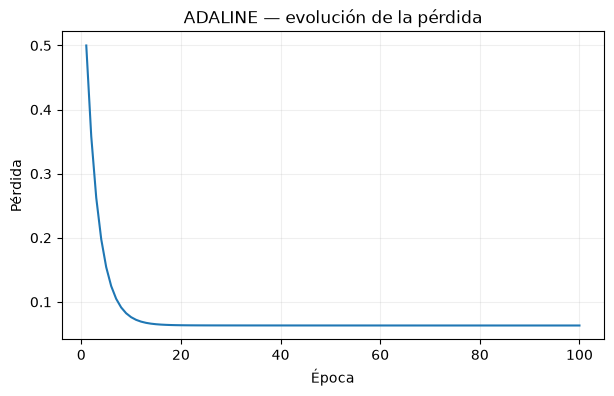

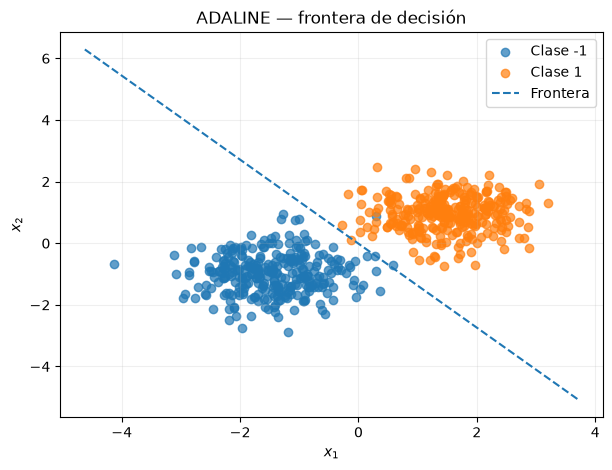

In [23]:
w_final, historial_final = entrenar_adaline(
    X_train,
    y_train,
    eta=0.05,
    max_epocas=100,
)

pred_train = predecir_adaline(X_train, w_final)
pred_val = predecir_adaline(X_val, w_final)
pred_test = predecir_adaline(X_test, w_final)

print(f"Exactitud train:      {exactitud(y_train, pred_train):.3f}")
print(f"Exactitud validation: {exactitud(y_val, pred_val):.3f}")
print(f"Exactitud test:       {exactitud(y_test, pred_test):.3f}")

graficar_perdida(
    historial_final,
    "ADALINE — evolución de la pérdida",
)

graficar_frontera(
    X,
    y,
    w_final,
    "ADALINE — frontera de decisión",
)

### Interprete

1. ¿la pérdida parece converger?;
2. ¿train, validation y test son comparables?;
3. ¿qué relación observa entre pérdida cuadrática y exactitud?;
4. ¿por qué la pérdida puede ser positiva aun con muchas clasificaciones correctas?

**Respuesta:**

> 1. Según la primer grafica en cuanto se emplean más epocas en el entrenamiento la función de perdida parece tender a un valor estable cercano a 0.
> 2. El modelo presenta un rendimiento consistente entre los conjuntos de entrenamiento, validación y prueba, con exactitudes de 99.5%, 98.9% y 100%, respectivamente. La reducida diferencia entre las métricas sugiere una buena capacidad de generalización y no evidencia un sobreajuste significativo.
> 3. Se observa una relación general entre ambas métricas: una menor pérdida cuadrática suele estar asociada con una mayor exactitud, ya que el modelo obtiene salidas lineales más cercanas a las etiquetas reales. Sin embargo, ambas métricas no son equivalentes. La pérdida cuadrática evalúa la magnitud del error de las salidas de ADALINE, mientras que la exactitud únicamente determina si la predicción final es correcta o incorrecta. 
> 4. La pérdida puede ser positiva aun cuando muchas clasificaciones sean correctas porque la pérdida cuadrática evalúa la distancia entre la salida lineal de ADALINE y la etiqueta real, mientras que la exactitud solo evalúa si la salida se encuentra en el lado correcto del umbral de clasificación. De esta forma, una predicción puede ser correctamente clasificada pero presentar un error cuadrático positivo.


# 16. ¿Qué ocurre si las características tienen escalas muy distintas?

Construiremos el mismo problema, pero reemplazaremos:

$$
x_2^\ast=10x_2.
$$

La información de clasificación no cambia, pero la geometría numérica sí.

In [24]:
X_escala = X.copy()
X_escala[:, 1] = 10.0 * X_escala[:, 1]

(
    X_train_e,
    y_train_e,
    X_val_e,
    y_val_e,
    X_test_e,
    y_test_e,
) = particion_estratificada(
    X_escala,
    y,
    semilla=2026,
)

print("Desviaciones de train:")
print(X_train_e.std(axis=0))

Desviaciones de train:
[ 1.6358  11.39046]


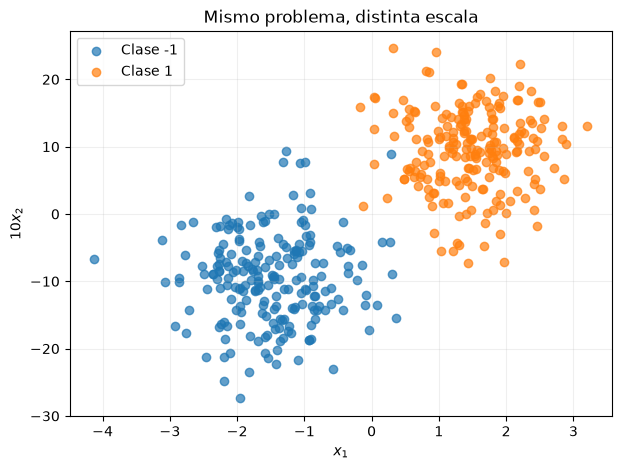

In [25]:
fig, ax = plt.subplots(figsize=(7, 5))

for etiqueta in (-1, 1):
    mascara = y_train_e == etiqueta
    ax.scatter(
        X_train_e[mascara, 0],
        X_train_e[mascara, 1],
        alpha=0.7,
        label=f"Clase {etiqueta}",
    )

ax.set_xlabel("$x_1$")
ax.set_ylabel("$10x_2$")
ax.set_title("Mismo problema, distinta escala")
ax.legend()
ax.grid(alpha=0.2)
plt.show()

## 16.1 Entrene sin estandarizar

Use:

$$
\eta=0.05.
$$

Si la pérdida se comporta mal, no cambie de inmediato el algoritmo. Observe primero.

Primeras pérdidas:


,epoca,perdida
0,1,0.500000
1,2,11.039043
2,3,337.774925
3,4,10459.085543
4,5,323979.939312


Últimas pérdidas:


,epoca,perdida
45,46,4.392607e+66
46,47,1.360667e+68
47,48,4.214840e+69
48,49,1.305601e+71
49,50,4.044268e+72


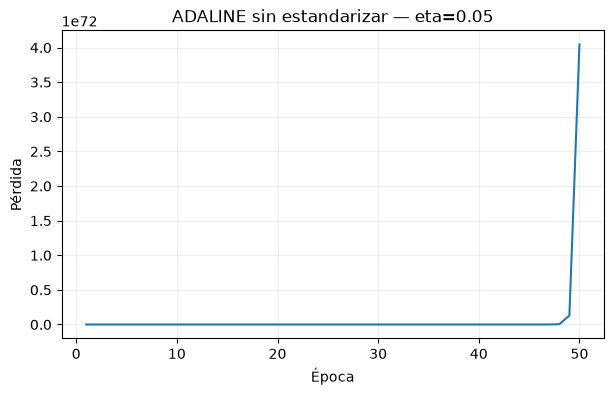

In [26]:
w_escala, hist_escala = entrenar_adaline(
    X_train_e,
    y_train_e,
    eta=0.05,
    max_epocas=50,
)

tabla_escala = historial_a_dataframe(hist_escala)

print("Primeras pérdidas:")
display(tabla_escala[["epoca", "perdida"]].head())

print("Últimas pérdidas:")
display(tabla_escala[["epoca", "perdida"]].tail())

graficar_perdida(
    hist_escala,
    "ADALINE sin estandarizar — eta=0.05",
)

### Observe

Si la pérdida aumenta u oscila:

> ¿qué cambió respecto al experimento anterior si las etiquetas y el problema conceptual son los mismos?

**Respuesta:**

> > Aunque las etiquetas y el problema de clasificación son los mismos, al utilizar datos no estandarizados cambia la escala de las variables de entrada. Esto modifica la magnitud del gradiente y, por tanto, el tamaño efectivo de las actualizaciones de los pesos. En el experimento se observa que la pérdida aumenta a medida que avanzan las épocas, lo que indica que, para el valor de $\eta$ utilizado, el proceso de entrenamiento puede estar realizando actualizaciones demasiado grandes y alejándose del mínimo de la función de pérdida. Por tanto, el cambio en la escala de los datos afecta directamente la convergencia y estabilidad del algoritmo ADALINE.


# 17. Estandarización

Usaremos únicamente estadísticas de train:

$$
x_j^{\mathrm{std}}
=
\frac{x_j-\mu_j^{(\mathrm{train})}}
{\sigma_j^{(\mathrm{train})}}.
$$

Validation y test se transforman con esos mismos parámetros.

In [27]:
(
    X_train_std,
    X_val_std,
    X_test_std,
    media_train,
    desviacion_train,
) = estandarizar_desde_train(
    X_train_e,
    X_val_e,
    X_test_e,
)

print("Media de train estandarizado:")
print(X_train_std.mean(axis=0))

print("\nDesviación de train estandarizado:")
print(X_train_std.std(axis=0))

Media de train estandarizado:
[-0.  0.]

Desviación de train estandarizado:
[1. 1.]


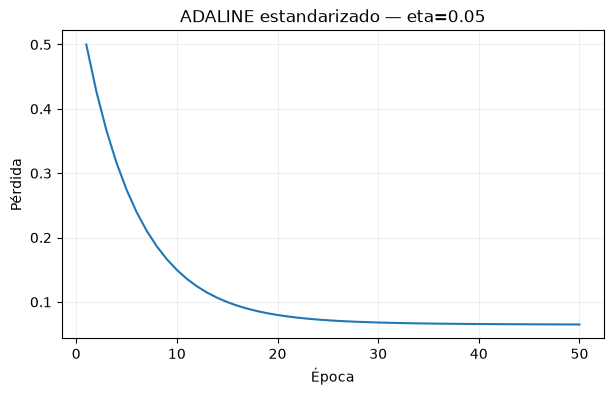

Exactitud train:      0.998
Exactitud validation: 1.000
Exactitud test:       1.000


In [28]:
w_std, hist_std = entrenar_adaline(
    X_train_std,
    y_train_e,
    eta=0.05,
    max_epocas=50,
)

graficar_perdida(
    hist_std,
    "ADALINE estandarizado — eta=0.05",
)

pred_train_std = predecir_adaline(X_train_std, w_std)
pred_val_std = predecir_adaline(X_val_std, w_std)
pred_test_std = predecir_adaline(X_test_std, w_std)

print(f"Exactitud train:      {exactitud(y_train_e, pred_train_std):.3f}")
print(f"Exactitud validation: {exactitud(y_val_e, pred_val_std):.3f}")
print(f"Exactitud test:       {exactitud(y_test_e, pred_test_std):.3f}")

### Compare

1. ¿qué ocurrió sin estandarizar?;
2. ¿qué cambió después?;
3. ¿por qué la escala afecta gradient descent?;
4. ¿qué relación encuentra entre escala, gradiente y learning rate?

**Respuesta:**

> 1. Sin estandarizar los datos, la pérdida no presentó un comportamiento adecuado de convergencia y, en particular, se observó que podía aumentar a medida que avanzaban las épocas. Esto indica que el proceso de descenso por gradiente era inestable para la escala original de las variables. 
> 2. Después de estandarizar los datos, la gráfica de épocas frente a pérdida mostró un comportamiento decreciente: la pérdida disminuyó conforme aumentó el número de épocas. Además, se alcanzó una pérdida baja utilizando menos épocas que con los datos originales. La exactitud también mejoró y se mantuvo muy alta, obteniéndose una exactitud de (0.998) en entrenamiento, (1.000) en validación y (1.000) en prueba. Esto indica un entrenamiento más estable y una buena capacidad de generalización.
> 3. Se tiene que $\nabla L(\mathbf w_t)= -\frac{1}{n}X^T(\mathbf y-\mathbf a)$ luego, al estandarizar las variables, sus escalas se vuelven comparables y se controla la magnitud del gradiente.
> 4. Se tiene que $\mathbf w_{t+1}=\mathbf w_t-\eta\nabla L(\mathbf w_t).$ En cuanto las variables tienen una escala muy grande, el gradiente puede ser grande y un mismo valor de $\eta$ puede producir actualizaciones excesivas e inestables. Al estandarizar los datos, la magnitud del gradiente se vuelve más controlable, por lo que el mismo learning rate puede producir actualizaciones más apropiadas.

# 18. Una mirada computacional

Si:

$$
\tilde X\in\mathbb R^{n\times(d+1)},
$$

la actualización contiene:

$$
\tilde X\mathbf w
\quad\text{y}\quad
\tilde X^\top\mathbf e.
$$

Responda:

1. ¿cuál es el costo dominante de una época?;
2. ¿cuál es el costo de $E$ épocas?;
3. ¿qué costo adicional tiene almacenar una copia de $\mathbf w$ por época?

**Respuesta:**

> 1. 
> 2. 
> 3. 

# 19. Perceptrón vs. ADALINE

Complete:

| Aspecto | Perceptrón | ADALINE |
|---|---|---|
| Entrada neta | $z=\tilde{X}\mathbf{w}$ | $z=\tilde{X}\mathbf{w}$ |
| Etiquetas | $y\in\{-1,+1\}$ | $y\in\{-1,+1\}$ |
| Salida usada durante aprendizaje | $\hat{y}=\operatorname{sign}(z)$ | $a=z$ (salida lineal) |
| Criterio de cambio de pesos | Cambia cuando hay una clasificación incorrecta | Actualiza los pesos en cada época mediante el gradiente |
| Función de pérdida explícita | No necesariamente; utiliza el error de clasificación | $L(\mathbf{w})=\frac{1}{2n}\sum_{i=1}^{n}(y_i-a_i)^2$ |
| ¿Usa gradiente? | No | Sí, descenso por gradiente |
| Actualizaciones por época en la versión estudiada | Una actualización por cada observación mal clasificada | Una única actualización por época (batch) |
| Papel de `sign` | Determina la salida utilizada para decidir si actualizar | Se utiliza después del aprendizaje para convertir la salida lineal en una clase |
| Sensibilidad a escala | Sí | Sí, especialmente importante por el cálculo del gradiente |

Después responda:

> **¿Por qué ADALINE constituye un puente conceptual entre el perceptrón y las redes neuronales entrenadas mediante gradient descent?**

**Respuesta:**

> ADALINE constituye un puente conceptual entre el perceptrón y las redes neuronales entrenadas mediante gradient descent porque mantiene la estructura básica del perceptrón, pero reemplaza el criterio de clasificación utilizado para el aprendizaje por una función de pérdida diferenciable. ADALINE introduce conceptos fundamentales del entrenamiento de redes neuronales, como la función de pérdida, el gradiente y la tasa de aprendizaje.

# 20. Vuelva a mirar su arquitectura

1. ¿tuvo que modificar su diseño inicial?;
2. ¿qué función terminó teniendo la responsabilidad más compleja?;
3. ¿hay una función con demasiadas responsabilidades?;
4. ¿qué refactorización haría si el proyecto creciera?;
5. ¿dónde ubicó las validaciones y por qué?;
6. ¿qué pieza podría reutilizar en otro modelo entrenado con gradient descent?

**Respuesta:**

> En el modelo inicial no tenía conceptualizada la necesidad de determinar un historial, pues no había considerado que, además de obtener los pesos finales, era necesario registrar la evolución de la pérdida durante las épocas para analizar el entrenamiento. Por esta razón, tuve que modificar el diseño inicial para incorporar el almacenamiento de la época, la pérdida y los pesos. Inicialmente, la función que percibía como más compleja era `actualizar_pesos_adaline`, pero durante la implementación observé que sus responsabilidades podían dividirse en funciones más pequeñas, como `entrada_neta`, `clasificacion_error` y `calculo_gradiente`. De esta manera, cada función quedó encargada de una tarea específica y `entrenar_adaline` pasó a coordinar el proceso general. Las validaciones se ubicaron dentro de las funciones para verificar desde el principio que las dimensiones, tipos y valores fueran correctos y evitar que datos inválidos se propagaran. Finalmente, la pieza que podría reutilizar en otros modelos entrenados mediante *gradient descent* sería la estructura general de calcular una pérdida, obtener su gradiente y actualizar los parámetros mediante una tasa de aprendizaje, además del registro del historial para estudiar la convergencia.


# 21. Calidad y entrega

Antes de entregar:

1. reinicie el kernel;
2. ejecute **Run All**;
3. compruebe que no existen errores;
4. verifique que su arquitectura coincide con su implementación;
5. ejecute sus pruebas;
6. interprete las curvas de pérdida;
7. confirme que no modificó `actualizar_pesos_adaline`;
8. no suba el ambiente virtual.

En terminal:

```bash
ruff check .
```

y:

```bash
git status
```

Después:

```bash
git add .
git commit -m "Implementa ADALINE con arquitectura funcional"
git pull
git push
```

## Criterio de finalización

El ejercicio está completo cuando puede defender:

$$
\boxed{
\text{formulación matemática}
\rightarrow
\text{arquitectura}
\rightarrow
\text{implementación}
\rightarrow
\text{pruebas}
\rightarrow
\text{optimización}
\rightarrow
\text{evaluación}
}
$$